# TP : Construire un Transformer from Scratch avec Keras 3.0

Implémenter **chaque composant** de l'architecture Transformer (Vaswani et al., 2017) de zéro :

| Composant | Section | Statut |
|---|---|---|
| Encodage Positionnel | Partie 1 | Fourni |
| Scaled Dot-Product Attention | Partie 2 | **À implémenter** |
| Multi-Head Attention | Partie 3 | **À implémenter** |
| Feed-Forward Network | Partie 4 | Fourni |
| Encoder Layer (Self-Attn + Add & Norm + FFN) | Partie 5 | **À implémenter** |
| Decoder Layer (Masked Self-Attn + Cross-Attn + FFN) | Partie 6 | **À implémenter** |
| Masques (padding + causal) | Partie 7 | Fourni |
| Assemblage du Transformer complet | Partie 8 | Fourni |

Puis **entraîner** le modèle sur une tâche d'inversion de chaînes (`ABCD → DCBA`) et **visualiser** les matrices d'attention apprises.

## Stack technique

- **Keras 3.0**
- `keras.ops` pour toutes les opérations tensorielles (backend-agnostic)
- `keras.layers.Layer` pour les composants, `keras.Model` pour le modèle complet

In [62]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import ops, layers
import numpy as np
import math
import random
import string
import matplotlib.pyplot as plt

random.seed(42)

---
## Données : Vocabulaire & Hyperparamètres

Nous travaillons sur l'**inversion de chaînes** : traduire `HELLO` en `OLLEH`. C'est une tâche seq2seq simple qui nécessite néanmoins toute l'architecture Encodeur-Décodeur.

In [63]:

PAD_TOKEN, SOS_TOKEN, EOS_TOKEN = "<pad>", "<sos>", "<eos>"
vocab = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + list(string.ascii_uppercase)
vocab_size = len(vocab)
char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
PAD_IDX, SOS_IDX, EOS_IDX = 0, 1, 2

# Hyperparamètres du Transformer
D_MODEL = 64
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 128 
DROPOUT_RATE = 0.1
MAX_LEN = 50

#  Entraînement Paramètres
NUM_SAMPLES = 8000
BATCH_SIZE = 64
EPOCHS = 25
LEARNING_RATE = 1e-3
MIN_SEQ_LEN, MAX_SEQ_LEN = 3, 10

print(f"Vocab ({vocab_size}) : {vocab}")
print(f"Transformer : d_model={D_MODEL}, heads={NUM_HEADS}, layers={NUM_LAYERS}, d_ff={D_FF}")

Vocab (29) : ['<pad>', '<sos>', '<eos>', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Transformer : d_model=64, heads=4, layers=2, d_ff=128


---
## Génération des données

In [64]:

def generate_dataset(num_samples, min_len, max_len):
    """Génère des paires (source, target) pour l'inversion de chaînes."""
    sources, targets = [], []
    for _ in range(num_samples):
        length = random.randint(min_len, max_len)
        chars = [random.choice(string.ascii_uppercase) for _ in range(length)]
        sources.append([char_to_idx[c] for c in chars])
        targets.append([SOS_IDX] + [char_to_idx[c] for c in reversed(chars)] + [EOS_IDX])
    
    # Padding
    max_src = max(len(s) for s in sources)
    max_tgt = max(len(t) for t in targets)
    src = np.array([s + [PAD_IDX] * (max_src - len(s)) for s in sources])
    tgt = np.array([t + [PAD_IDX] * (max_tgt - len(t)) for t in targets])
    return src, tgt

src_data, tgt_data = generate_dataset(NUM_SAMPLES, MIN_SEQ_LEN, MAX_SEQ_LEN)

# Decoder input  = <sos> D C B A     (tout sauf le dernier)
# Decoder target  = D C B A <eos>     (tout sauf le premier)
tgt_input = tgt_data[:, :-1]
tgt_output = tgt_data[:, 1:]

print(f"Source shape    : {src_data.shape}")
print(f"Tgt input shape : {tgt_input.shape}")
print(f"Tgt output shape: {tgt_output.shape}")

# Exemple
i = 0
print(f"  Source     : {''.join(idx_to_char[x] for x in src_data[i] if x != PAD_IDX)}")
print(f"  Tgt input  : {' '.join(idx_to_char[x] for x in tgt_input[i] if x != PAD_IDX)}")
print(f"  Tgt output : {' '.join(idx_to_char[x] for x in tgt_output[i] if x != PAD_IDX)}")

Source shape    : (8000, 10)
Tgt input shape : (8000, 11)
Tgt output shape: (8000, 11)
  Source     : AXIH
  Tgt input  : <sos> H I X A <eos>
  Tgt output : H I X A <eos>


---
## Partie 1 : Encodage Positionnel

Le Transformer n'a **aucune notion d'ordre** (contrairement aux RNN). On injecte l'information de position via des sinusoïdes :

$$PE_{(pos, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right), \quad PE_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

In [65]:
class PositionalEncoding(layers.Layer):
    def __init__(self, d_model, max_len=5000, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.dropout = layers.Dropout(dropout_rate)

        # pré-calculer la matrice PE
        position = np.arange(max_len).reshape(-1, 1)
        div_term = np.exp(np.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        pe = np.zeros((1, max_len, d_model))
        pe[0, :, 0::2] = np.sin(position * div_term)
        pe[0, :, 1::2] = np.cos(position * div_term)
        self.pe = ops.convert_to_tensor(pe, dtype="float32")

    def call(self, x, training=False):
        seq_len = ops.shape(x)[1]
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x, training=training)

---
## Partie 2 : Scaled Dot-Product Attention

Le cœur du Transformer. On calcule :

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Le `mask` (optionnel) met à $-\infty$ les positions interdites **avant** le softmax.

In [ ]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """
    Args:
        query : (batch, heads, seq_q, d_k)
        key   : (batch, heads, seq_k, d_k)
        value : (batch, heads, seq_k, d_v)
        mask  : broadcastable, 1 = visible, 0 = masqué
    Returns:
        output           : (batch, heads, seq_q, d_v)
        attention_weights: (batch, heads, seq_q, seq_k)
    """
    # TODO:
    # 1. Scores = Q @ K^T / sqrt(d_k)
    # 2. Appliquer le masque (les 0 deviennent -1e9 → softmax → 0)
    # 3. Softmax
    # 4. Somme pondérée des Values

    output, attention_weights = ???

    return output, attention_weights

---
## Partie 3 : Multi-Head Attention

Au lieu d'une seule attention de dimension $d_{model}$, on utilise $h$ têtes en parallèle, chacune de dimension $d_k = d_{model} / h$. Chaque tête capture un **type de relation différent**.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) \cdot W^O$$

In [ ]:
class MultiHeadAttention(layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = layers.Dense(d_model)
        self.W_k = layers.Dense(d_model)
        self.W_v = layers.Dense(d_model)
        self.W_o = layers.Dense(d_model)

    def split_heads(self, x):
        """(batch, seq, d_model) → (batch, heads, seq, d_k)"""
        batch_size = ops.shape(x)[0]
        x = ops.reshape(x, (batch_size, -1, self.num_heads, self.d_k))
        return ops.transpose(x, axes=(0, 2, 1, 3))

    def call(self, query, key, value, mask=None):
        """
        Args:
            query, key, value : (batch, seq, d_model)
            mask : broadcastable to (batch, heads, seq_q, seq_k)
        Returns:
            output : (batch, seq_q, d_model)
            weights: (batch, heads, seq_q, seq_k)
        """
        # TODO:
        # 1. Projections linéaires
        # 2. Découper en têtes
        # 3. Attention
        # 4. Re-concaténer les têtes
        # 5. Projection de sortie


        
        return output, attn_weights

---
## Partie 4 : Feed-Forward Network

Appliqué indépendamment à chaque position :
$$\text{FFN}(x) = \max(0,\; xW_1 + b_1)\, W_2 + b_2$$

In [69]:
class FeedForward(layers.Layer):
    def __init__(self, d_model, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = layers.Dense(d_ff, activation="relu")
        self.dense2 = layers.Dense(d_model)
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        x = self.dense1(x)
        x = self.dropout(x, training=training)
        x = self.dense2(x)
        return x

---
## Partie 5 : Encoder Layer

Un bloc encodeur = **Self-Attention → Add & Norm → FFN → Add & Norm**.

La connexion résiduelle (`x + sublayer(x)`) permet aux gradients de circuler directement, et la Layer Normalization stabilise l'entraînement.

In [ ]:
class EncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout_rate)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, mask=None, training=False):
        # TODO:
        # 1. Self-attention + résiduelle + norm
        # 2. Feed-forward + résiduelle + norm    
        
     
        return x, attn_weights

---
## Partie 6 : Decoder Layer

Un bloc décodeur a **3 sous-couches** :
1. **Masked Self-Attention** (le décodeur ne voit pas le futur)
2. **Cross-Attention** ($Q$ du décodeur, $K/V$ de l'encodeur)
3. **Feed-Forward**

Chaque sous-couche est suivie de Add & Norm.

In [ ]:
class DecoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.masked_mha = MultiHeadAttention(d_model, num_heads)
        self.cross_mha  = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout_rate)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
        self.dropout3 = layers.Dropout(dropout_rate)

    def call(self, x, enc_output, look_ahead_mask=None, src_padding_mask=None, training=False):
        """
        Args:
            x               : (batch, tgt_len, d_model)
            enc_output      : (batch, src_len, d_model)
            look_ahead_mask : causal + padding mask pour self-attention
            src_padding_mask: padding mask de la source pour cross-attention
        """
        # TODO:
        # 1. Masked self-attention + Add & Norm
        # 2. Cross-attention (Q=décodeur, K/V=encodeur) + Add & Norm
        # 3. Feed-forward + Add & Norm

        return x, self_attn_w, cross_attn_w

---
## Partie 7 : Masques

Deux masques sont nécessaires :
1. **Padding mask** : empêcher l'attention sur les tokens `<pad>` (convention : 1 = visible, 0 = masqué).
2. **Causal mask** (look-ahead) : matrice triangulaire inférieure pour empêcher le décodeur de voir le futur.

In [72]:
def create_padding_mask(seq):
    """1 là où le token est réel, 0 là où c'est du padding.
    Shape : (batch, 1, 1, seq_len) — broadcastable sur (batch, heads, q_len, k_len)."""
    mask = ops.cast(seq != PAD_IDX, dtype="float32")
    return mask[:, None, None, :]     


def create_causal_mask(seq):
    """Combine le masque causal (triangulaire inférieur) et le masque de padding.
    Shape : (batch, 1, seq_len, seq_len)."""

    seq_len = ops.shape(seq)[1]

    # Triangulaire inférieur : 1 = visible, 0 = futur
    causal = ops.tril(ops.ones((seq_len, seq_len)))

    padding = create_padding_mask(seq)


    return causal[None, None, :, :] * padding

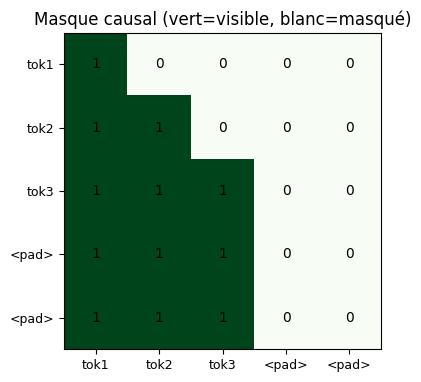

In [73]:
test_seq = np.array([[3, 4, 5, 0, 0]])
causal = create_causal_mask(test_seq)

plt.figure(figsize=(4, 4))
plt.imshow(causal[0, 0].cpu().numpy(), cmap='Greens', vmin=0, vmax=1)
plt.title("Masque causal (vert=visible, blanc=masqué)")
labels = ["tok1", "tok2", "tok3", "<pad>", "<pad>"]
plt.xticks(range(5), labels, fontsize=9)
plt.yticks(range(5), labels, fontsize=9)
for i in range(5):
    for j in range(5):
        v = causal[0, 0, i, j].cpu().numpy()
        plt.text(j, i, f"{v:.0f}", ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Partie 8 : Transformer complet

On assemble tous les composants dans un `keras.Model` :

- **Encodeur** : Embedding → Positional Encoding → $N \times$ EncoderLayer
- **Décodeur** : Embedding → Positional Encoding → $N \times$ DecoderLayer
- **Sortie**   : Dense(vocab_size) → logits

In [74]:
class Transformer(keras.Model):
    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_len=100, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model

        # Embeddings (partagés encodeur/décodeur pour cette petite tâche)
        self.embedding = layers.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout_rate)

        #  encodeur & décodeur
        self.enc_layers = [
            EncoderLayer(d_model, num_heads, d_ff, dropout_rate)
            for _ in range(num_layers)
        ]
        self.dec_layers = [
            DecoderLayer(d_model, num_heads, d_ff, dropout_rate)
            for _ in range(num_layers)
        ]

        # Projection finale
        self.final_dense = layers.Dense(vocab_size)

        # Stocker les poids d'attention pour la visualisation
        self.last_attn_weights = {}

    def encode(self, src, mask, training):
        x = self.embedding(src) * ops.sqrt(ops.cast(self.d_model, "float32"))
        x = self.pos_encoding(x, training=training)
        for i, layer in enumerate(self.enc_layers):
            x, w = layer(x, mask, training=training)
            self.last_attn_weights[f"enc_{i}"] = w
        return x

    def decode(self, tgt, enc_output, look_ahead_mask, src_mask, training):
        x = self.embedding(tgt) * ops.sqrt(ops.cast(self.d_model, "float32"))
        x = self.pos_encoding(x, training=training)
        for i, layer in enumerate(self.dec_layers):
            x, sw, cw = layer(x, enc_output, look_ahead_mask, src_mask, training=training)
            self.last_attn_weights[f"dec_{i}_self"] = sw
            self.last_attn_weights[f"dec_{i}_cross"] = cw
        return x

    def call(self, inputs, training=False):
        src, tgt = inputs

        # 1. Créer les masques
        src_mask = create_padding_mask(src) # pour l'encodeur + cross-attention
        tgt_mask = create_causal_mask(tgt) # causal + padding pour le décodeur

        enc_output = self.encode(src, src_mask, training)

        dec_output = self.decode(tgt, enc_output, tgt_mask, src_mask, training)

        logits = self.final_dense(dec_output)
        return logits

---
## Entraînement

In [75]:
def masked_loss(y_true, y_pred):
    mask = ops.cast(y_true != PAD_IDX, dtype="float32")
    loss = keras.losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=True)
    return ops.sum(loss * mask) / (ops.sum(mask) + 1e-8)

def masked_accuracy(y_true, y_pred):
    mask = ops.cast(y_true != PAD_IDX, dtype="float32")
    preds = ops.cast(ops.argmax(y_pred, axis=-1), dtype=y_true.dtype)
    correct = ops.cast(preds == y_true, dtype="float32") * mask
    return ops.sum(correct) / (ops.sum(mask) + 1e-8)

In [76]:
model = Transformer(
    vocab_size=vocab_size,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    dropout_rate=DROPOUT_RATE,
)

model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss=masked_loss,
    metrics=[masked_accuracy],
)

_ = model([src_data[:2], tgt_input[:2]])
model.summary()

Model: "transformer_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (2, 10, 64)            │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_7           │ ?                      │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_6 (EncoderLayer)  │ ?                      │        33,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_7 (EncoderLayer)  │ ?                      │        33,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer_6 (DecoderLayer)  │ ?                      │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer_7 (DecoderLayer)  │ ?                      │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (2, 11, 29)            │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,165 (668.61 KB)

 Trainable params: 171,165 (668.61 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
history = model.fit(
    [src_data, tgt_input],
    tgt_output,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
)

Epoch 1/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 2.6729 - masked_accuracy: 0.2452 - val_loss: 1.4025 - val_masked_accuracy: 0.5499
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 1.2613 - masked_accuracy: 0.6096 - val_loss: 0.3834 - val_masked_accuracy: 0.8730
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.6147 - masked_accuracy: 0.8118 - val_loss: 0.0924 - val_masked_accuracy: 0.9780
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 0.3618 - masked_accuracy: 0.8902 - val_loss: 0.0131 - val_masked_accuracy: 0.9986
Epoch 5/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.2539 - masked_accuracy: 0.9230 - val_loss: 0.0207 - val_masked_accuracy: 0.9952
Epoch 6/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.2100 - masked_accuracy: 0.9369 - val_loss: 0.0148 - val_masked_accuracy: 0.9955
Epoch 7/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.1521 - masked_accuracy: 0.9561 - val_loss: 0.0024 - val_masked_accuracy: 0.9998

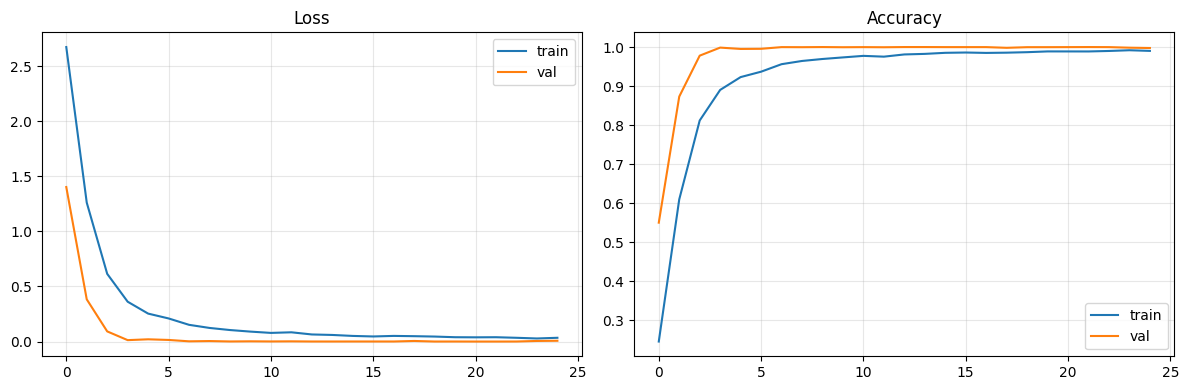

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['masked_accuracy'], label='train')
axes[1].plot(history.history['val_masked_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Inférence auto-régressive

Le décodeur génère **un token à la fois**, en réinjectant sa prédiction précédente.

In [79]:
def reverse_string(model, input_str, max_len=30):
    """Inversion auto-régressive d'une chaîne."""
    src = np.array([[char_to_idx[c] for c in input_str]])
    ys = np.array([[SOS_IDX]])

    for _ in range(max_len):
        logits = model([src, ys], training=False)
        next_token = int(ops.argmax(logits[:, -1, :], axis=-1)[0])
        ys = np.concatenate([ys, [[next_token]]], axis=1)
        if next_token == EOS_IDX:
            break

    return "".join(idx_to_char[t] for t in ys[0] if t not in (SOS_IDX, EOS_IDX, PAD_IDX))


test_strings = ["HELLO", "ABCDE", "WORLD", "XYZ", "KERAS", "AI"]
print(f"{'Entrée':>12s} | {'Attendu':>12s} | {'Prédit':>12s} | OK ?")
print("-" * 55)
ok = 0
for s in test_strings:
    pred = reverse_string(model, s)
    exp = s[::-1]
    match = pred == exp
    ok += match
    print(f"{s:>12s} | {exp:>12s} | {pred:>12s} | {'OK' if match else 'ERREUR'}")
print(f"\nPrécision : {ok}/{len(test_strings)}")

      Entrée |      Attendu |       Prédit | OK ?
-------------------------------------------------------


/Users/gonthierlucas/Desktop/lbmg/fac/2025-2026/machine-learning/.venv/lib/python3.11/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape torch.Size([1, 4, 1, 1]). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


       HELLO |        OLLEH |        OLLEH | OK
       ABCDE |        EDCBA |        EDCBA | OK
       WORLD |        DLROW |        DLROW | OK
         XYZ |          ZYX |          ZYX | OK
       KERAS |        SAREK |        SAREK | OK
          AI |           IA |           IA | OK

Précision : 6/6


---
## Visualisation de l'attention

Visualisons la **cross-attention** du décodeur : pour l'inversion de chaînes, on s'attend à un pattern **anti-diagonal** (le 1er token de sortie regarde le dernier token d'entrée).

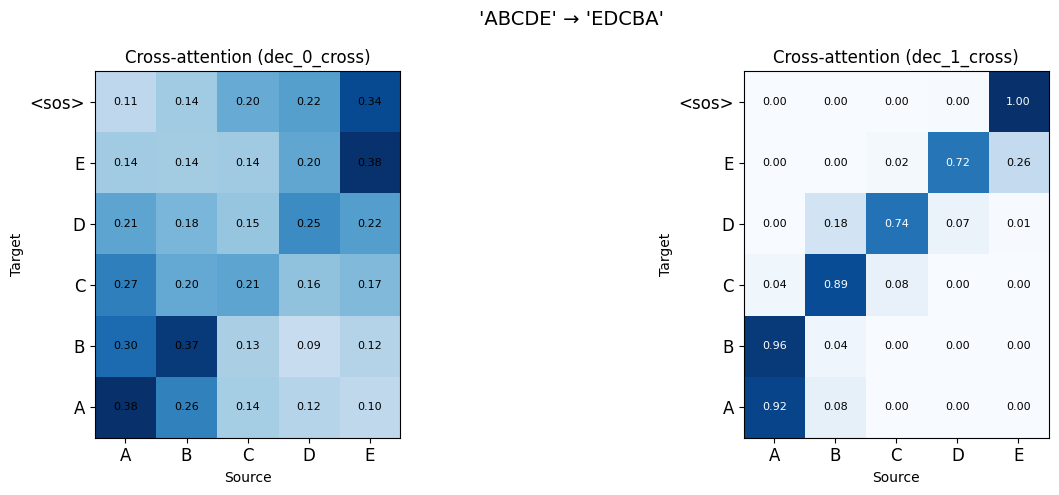

In [80]:
def plot_cross_attention(model, input_str):
    """Visualise la cross-attention du décodeur."""
    src = np.array([[char_to_idx[c] for c in input_str]])
    reversed_str = input_str[::-1]
    tgt = np.array([[SOS_IDX] + [char_to_idx[c] for c in reversed_str]])

    _ = model([src, tgt], training=False)

    src_tokens = list(input_str)
    tgt_tokens = ["<sos>"] + list(reversed_str)

    # Afficher la cross-attention de chaque couche du décodeur
    cross_keys = [k for k in model.last_attn_weights if "cross" in k]
    fig, axes = plt.subplots(1, len(cross_keys), figsize=(7 * len(cross_keys), 5))
    if len(cross_keys) == 1:
        axes = [axes]

    for idx, key in enumerate(cross_keys):
        # Moyenner sur les têtes
        attn = model.last_attn_weights[key][0].detach().cpu().numpy()
        attn_avg = attn.mean(axis=0)

        im = axes[idx].imshow(attn_avg, cmap='Blues', vmin=0)
        axes[idx].set_xticks(range(len(src_tokens)))
        axes[idx].set_xticklabels(src_tokens, fontsize=12)
        axes[idx].set_yticks(range(len(tgt_tokens)))
        axes[idx].set_yticklabels(tgt_tokens, fontsize=12)
        axes[idx].set_xlabel("Source")
        axes[idx].set_ylabel("Target")
        axes[idx].set_title(f"Cross-attention ({key})")
        for r in range(attn_avg.shape[0]):
            for c in range(attn_avg.shape[1]):
                axes[idx].text(c, r, f"{attn_avg[r, c]:.2f}", ha='center', va='center',
                              fontsize=8, color='white' if attn_avg[r, c] > 0.4 else 'black')

    plt.suptitle(f"'{input_str}' → '{input_str[::-1]}'", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_cross_attention(model, "ABCDE")

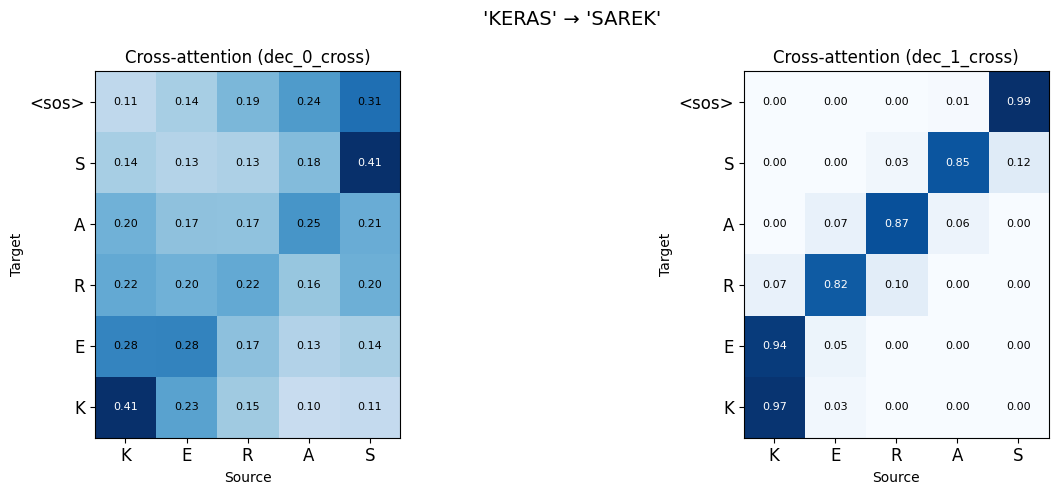

In [81]:
plot_cross_attention(model, "KERAS")